In [1]:
from test import *
import cv2
import supervision as sv
from ultralytics import YOLOWorld, YOLO
import numpy as np

d:\Anaconda3\envs\yolov7_custom\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



0: 640x384 2 persons, 3 backpacks, 1 dog, 1 eye, 1 nose, 2 tongues, 60.4ms
Speed: 100.2ms preprocess, 60.4ms inference, 72.0ms postprocess per image at shape (1, 3, 640, 384)


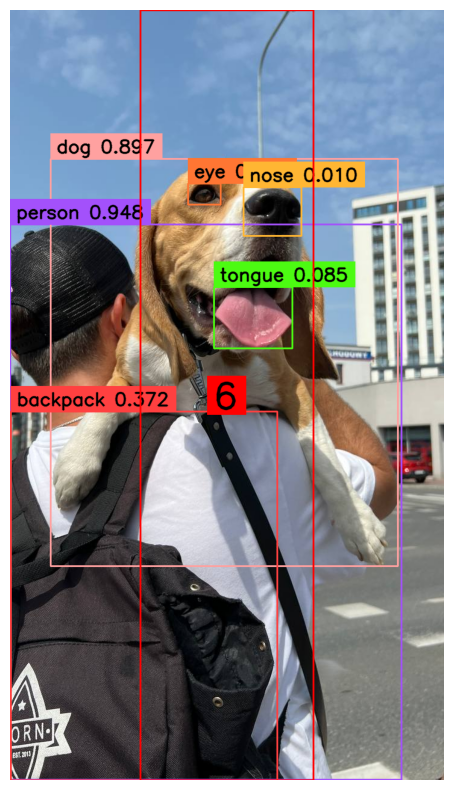

In [2]:
BOUNDING_BOX_ANNOTATOR = sv.BoundingBoxAnnotator(thickness=2)
LABEL_ANNOTATOR = sv.LabelAnnotator(text_thickness=2, text_scale=1, text_color=sv.Color.BLACK)
ZONE_POLYGON = np.array([
    [0.3, 0],
    [0.7, 0],
    [0.7, 1],
    [0.3, 1]
])

model_id = 'yolov8l-world.pt'
classes = ["person", "backpack", "dog", "eye", "nose", "ear", "tongue"]
source_path = "dog.jpeg"
confidence = 0.003
nms_threshold = 0.1

model = YOLOWorld(model=model_id)
if classes:
    model.set_classes(classes)

image = cv2.imread(source_path)
zone = sv.PolygonZone(polygon=(ZONE_POLYGON * np.array([720, 1280])).astype(int), frame_resolution_wh=tuple([720, 1280]))
zone_annotator = sv.PolygonZoneAnnotator(zone=zone, color=sv.Color.RED, thickness=2, text_thickness=4, text_scale=2)
results = model.predict(image, conf=confidence)
detections = sv.Detections.from_ultralytics(results[0]).with_nms(threshold=nms_threshold)
mask = zone.trigger(detections=detections)

annotated_image = image.copy()
annotated_image = BOUNDING_BOX_ANNOTATOR.annotate(annotated_image, detections=detections)

if classes:
    labels = [
        f"{classes[class_id]} {confidence:0.3f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]
    annotated_image = LABEL_ANNOTATOR.annotate(annotated_image, detections=detections, labels=labels)
annotated_image = zone_annotator.annotate(scene=annotated_image)

sv.plot_image(annotated_image, (10, 10))

In [6]:
print(results[0])

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'backpack', 2: 'dog', 3: 'eye', 4: 'nose', 5: 'ear', 6: 'tongue'}
obb: None
orig_img: array([[[202, 157, 120],
        [202, 157, 120],
        [202, 157, 120],
        ...,
        [199, 161, 129],
        [198, 160, 128],
        [198, 160, 128]],

       [[201, 156, 119],
        [201, 156, 119],
        [201, 156, 119],
        ...,
        [199, 161, 129],
        [199, 161, 129],
        [198, 160, 128]],

       [[201, 156, 119],
        [201, 156, 119],
        [201, 156, 119],
        ...,
        [200, 162, 130],
        [199, 161, 129],
        [199, 161, 129]],

       ...,

       [[202, 204, 205],
        [220, 222, 223],
        [233, 235, 236],
        ...,
        [109, 124, 150],
        [112, 126, 154],
        [106, 123, 150]],

       [[197, 199, 200],
        [225, 227, 228],
        [220, 222, 223],
       

In [9]:
model.model.names

['person', 'backpack', 'dog', 'eye', 'nose', 'ear', 'tongue']

In [10]:
type(results[0])

ultralytics.engine.results.Results

In [11]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'backpack', 2: 'dog', 3: 'eye', 4: 'nose', 5: 'ear', 6: 'tongue'}
obb: None
orig_img: array([[[202, 157, 120],
        [202, 157, 120],
        [202, 157, 120],
        ...,
        [199, 161, 129],
        [198, 160, 128],
        [198, 160, 128]],

       [[201, 156, 119],
        [201, 156, 119],
        [201, 156, 119],
        ...,
        [199, 161, 129],
        [199, 161, 129],
        [198, 160, 128]],

       [[201, 156, 119],
        [201, 156, 119],
        [201, 156, 119],
        ...,
        [200, 162, 130],
        [199, 161, 129],
        [199, 161, 129]],

       ...,

       [[202, 204, 205],
        [220, 222, 223],
        [233, 235, 236],
        ...,
        [109, 124, 150],
        [112, 126, 154],
        [106, 123, 150]],

       [[197, 199, 200],
        [225, 227, 228],
        [220, 222, 223],
       

In [12]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 2., 1., 6., 1., 3., 1., 4., 6., 0.], device='cuda:0')
conf: tensor([0.9483, 0.8971, 0.3721, 0.0852, 0.0281, 0.0135, 0.0117, 0.0099, 0.0053, 0.0034], device='cuda:0')
data: tensor([[2.9694e-01, 3.5679e+02, 6.4978e+02, 1.2797e+03, 9.4831e-01, 0.0000e+00],
        [6.7324e+01, 2.4769e+02, 6.4313e+02, 9.2447e+02, 8.9706e-01, 2.0000e+00],
        [1.1957e+00, 6.6790e+02, 4.4383e+02, 1.2800e+03, 3.7209e-01, 1.0000e+00],
        [3.3846e+02, 4.6025e+02, 4.6884e+02, 5.6297e+02, 8.5177e-02, 6.0000e+00],
        [1.5259e+00, 6.1789e+02, 6.2811e+02, 1.2796e+03, 2.8068e-02, 1.0000e+00],
        [2.9561e+02, 2.8805e+02, 3.4990e+02, 3.2311e+02, 1.3543e-02, 3.0000e+00],
        [1.4423e+00, 8.7090e+02, 4.4391e+02, 1.2795e+03, 1.1709e-02, 1.0000e+00],
        [3.8721e+02, 2.9463e+02, 4.8393e+02, 3.7518e+02, 9.8830e-03, 4.0000e+00],
        [2.9847e+02, 4.1784e+02, 4.7178e+02, 5.6529e+02, 5.3006e-03, 6.0000e+00],
        [0.0000

In [13]:
detections

Detections(xyxy=array([[    0.29694,      356.79,      649.78,      1279.7],
       [     67.324,      247.69,      643.13,      924.47],
       [     1.1957,       667.9,      443.83,        1280],
       [     338.46,      460.25,      468.84,      562.97],
       [     295.61,      288.05,       349.9,      323.11],
       [     387.21,      294.63,      483.93,      375.18]], dtype=float32), mask=None, confidence=array([    0.94831,     0.89706,     0.37209,    0.085177,    0.013543,    0.009883], dtype=float32), class_id=array([0, 2, 1, 6, 3, 4]), tracker_id=None, data={'class_name': array(['person', 'dog', 'backpack', 'tongue', 'eye', 'nose'], dtype='<U8')})

In [14]:
image.shape

(1280, 720, 3)

In [16]:
tuple([image.shape[1], image.shape[0]])

(720, 1280)

In [21]:
mask

array([ True,  True,  True,  True,  True,  True])

In [23]:
print(zone.current_count)
print(zone_annotator.zone.current_count)

6
6


In [5]:
ZONE_POLYGON = np.array([
    [0.3, 0],
    [0.7, 0],
    [0.7, 1],
    [0.3, 1]
])

ZONE_POLYGON * np.array([400, 400]).astype(int)

array([[        120,           0],
       [        280,           0],
       [        280,         400],
       [        120,         400]])